In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# Creating a Baseline Model

In [2]:
df = pd.read_csv('novagen_dataset.csv')
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


# EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [4]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [5]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [6]:
df.shape

(9549, 23)

# Data Preprocessing

<Axes: >

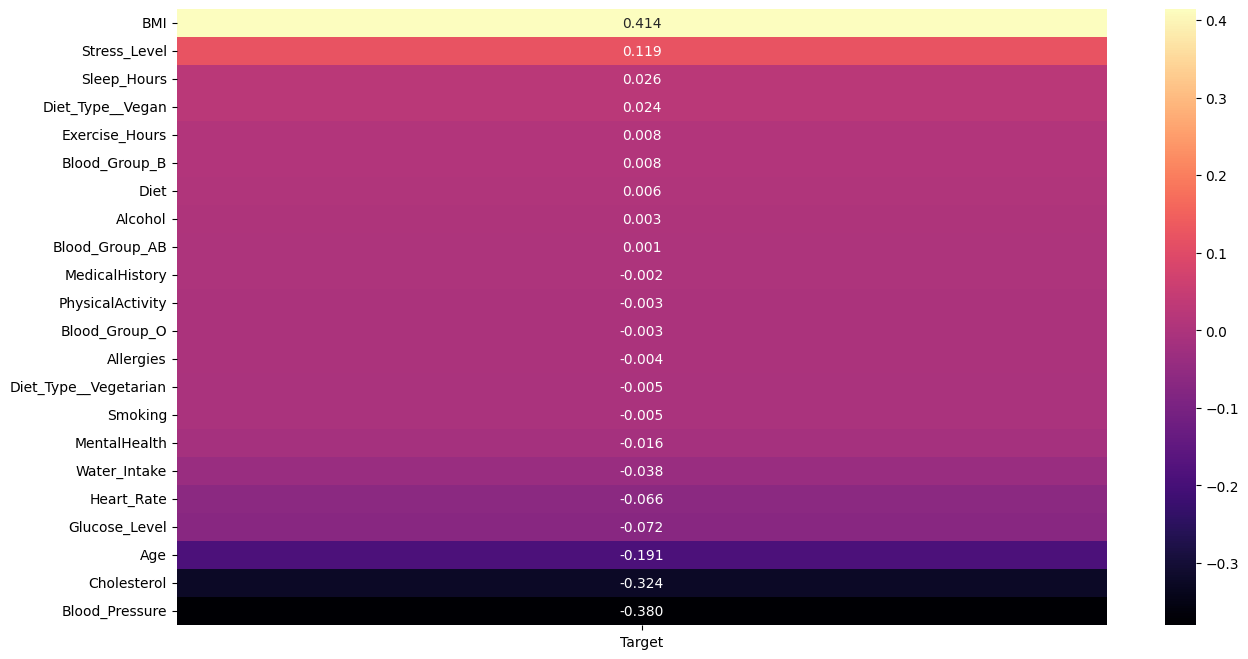

In [7]:
# creating correlation of x
plt.figure(figsize=(15,8))
sns.heatmap(df.corr()[['Target']].sort_values(by='Target', ascending=False).drop('Target'), 
            annot=True, cmap='magma',fmt='.3f')

In [8]:
# Split features and target
X = df.drop(columns=["Target"])
y = df["Target"]

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
ss = StandardScaler()

x_train_s = ss.fit_transform(X_train)
x_test_s = ss.transform(X_test)

# Model Training

In [11]:
# creating base models
lr = LogisticRegression(penalty='l2', max_iter=1000)

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

rfc = RandomForestClassifier(n_estimators=200,random_state=42)

gbc = GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,max_depth=3,random_state=42)

vc = VotingClassifier(estimators=[('lr',lr),('knn',knn),('rfc',rfc)],voting='soft')

In [12]:
# creating dictionary of models
models = {"Logistic Regression": lr,"KNN": knn,
"Random Forest": rfc, "Gradient Boosting Classifier":gbc, "Voting CClassifier":vc}

In [13]:
# creating result list
result=[]
for name,model in models.items():
    model.fit(x_train_s,y_train)
    y_pred=model.predict(x_test_s)
    Accuracy=(accuracy_score(y_test,y_pred)*100)
    Recall=(recall_score(y_test,y_pred)*100)
    result.append([name,Accuracy,Recall])

In [14]:
# creating results df
results=pd.DataFrame(result)
results.columns=['Model','Accuracy_Score','Recall_Score']
results = results.round(1)
results

,Model,Accuracy_Score,Recall_Score
0,Logistic Regression,81.4,82.7
1,KNN,88.3,88.4
2,Random Forest,94.0,96.2
3,Gradient Boosting Classifier,93.5,95.3
4,Voting CClassifier,91.6,93.0


# Model Comparison

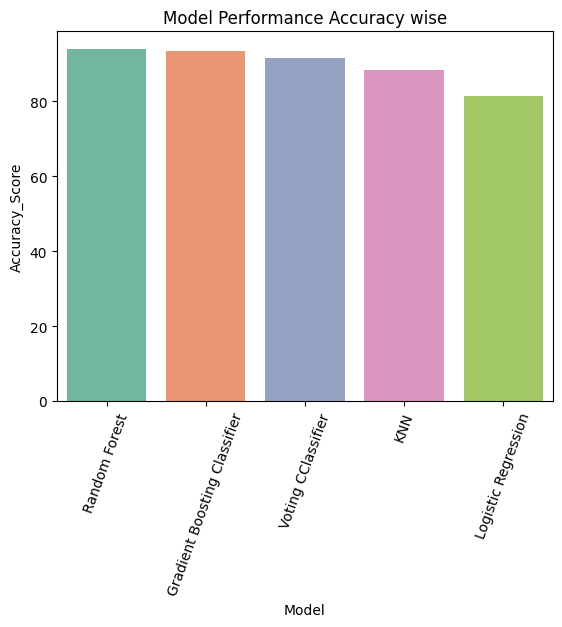

In [15]:
results_accuracy = results.sort_values(by='Accuracy_Score',ascending=False)

sns.barplot(data=results_accuracy,x='Model', y='Accuracy_Score',palette='Set2')
plt.title("Model Performance Accuracy wise")
plt.xticks(rotation=70)
plt.show()

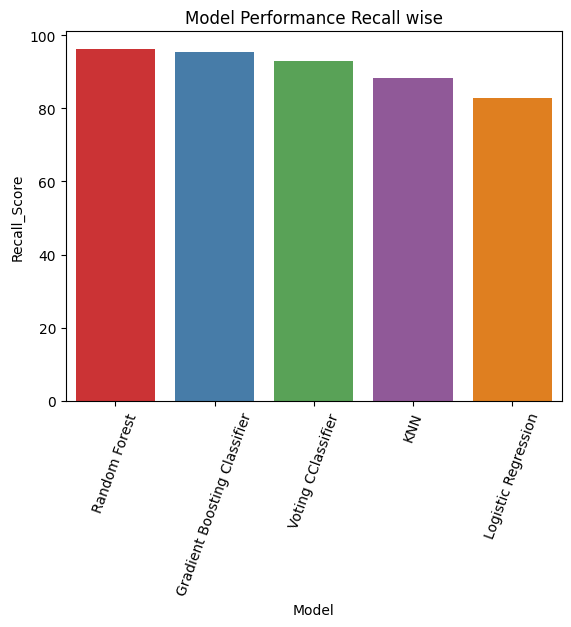

In [16]:
results_recall = results.sort_values(by='Recall_Score',ascending=False)

sns.barplot(data=results_recall,x='Model', y='Recall_Score',palette='Set1')
plt.title("Model Performance Recall wise")
plt.xticks(rotation=70)
plt.show()

### Result:
Best Model that we should use for NovaGen is Random Forest with Accuracy of 94.0% and Recall Value of 96.2%